# Thesis: Reclaimed Timber in Deep Generative Design

**Notebook:** c25_26_27_optimizer_workflow_with_cost_and_ILP  
**Author:** Jasper Cluistra     
**Last Updated:** 2026-02-27

## Cost and ILP Optimization Workflow

Generate a cost matrix for the geometry using timber datasets, then use ILP to find the best assignments.

**Inputs:** CSV timber dataset, Digital geometry  
**Outputs:** Best match for each structural element

# IMPORTING

In [1]:
import config
import json
import pandas as pd

file_path = config.TIMBER_STOCK_PATH / 'complete_timber.csv'
json_path = config.DATA_IO_PATH / "search_space.json"

with open(json_path, "r") as f:
    optimizer_search_space = json.load(f)

print(f"Search space loaded. The optimizer can control {len(optimizer_search_space)} parameters.")

# Try common combinations
read_attempts = [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(file_path, **opts)  # type: ignore
        # Valid if we get more than 1 column
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"Loaded with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse CSV with tested delimiter/encoding combinations.")

# Clean column names
df_input_stock.columns = df_input_stock.columns.str.strip()

print("Detected columns:", df_input_stock.columns.tolist())
print(f"\nDataset contains {df_input_stock.shape[0]} elements\n")
display(df_input_stock.head())

System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

GH data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\02_grasshopper_data
Geometry data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\01_geometry_data
Export directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports

Search space loaded. The optimizer can control 73 parameters.
Loaded with sep=';' and encoding='utf-8'
Detected columns: ['Member_ID', 'State', 'Length', 'Depth', 'Width', 'f_mk', 'f_tk', 'E_modulus_eff', 'E_modulus_005', 'f_vk', 'f_c0k', 'k_density', 'mean_density', 'Origin_Country', 'Transport_Dist', 'EmissionFactor']

Dataset contains 480 elements



,Member_ID,State,Length,Depth,Width,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,Origin_Country,Transport_Dist,EmissionFactor
0,NS_00000,0,1450.0,100.0,38.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,51.29,0.1769
1,NS_00001,0,1450.0,100.0,50.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,261.66,0.1757
2,NS_00002,0,1450.0,100.0,63.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,48.03,0.1772
3,NS_00003,0,1450.0,100.0,75.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,266.25,0.1775
4,NS_00004,0,1450.0,100.0,100.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,43.44,0.1769


# GEOMETRY

GRID: 5x3, EDGE_LENGTH: 3.0, LAYER_HEIGHT: 1.5, DIVISIONS: 8, NUM_SAMPLES: 20000

IMPACT_FACTOR_A1_A3: 0.25, IMPACT_FACTOR_RECOVERED_C1: 0.0085, "ENERGY_PREP_SAW_A5: 0.02, ENERGY_OFFCUT_FACTOR_C3_C4: 0.276, SCARCITY_PENALTY: 0

parameters loaded from c:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\c00_headquarter_params.py
Geometry: 39 nodes, 120 members
Length range [m]: 1.439 - 5.250


,edge_id,V1,V2,length_m
0,e0,0,1,3.000
1,e1,0,6,1.875
2,e2,1,2,2.250
3,e3,1,7,2.730
4,e4,2,3,4.125


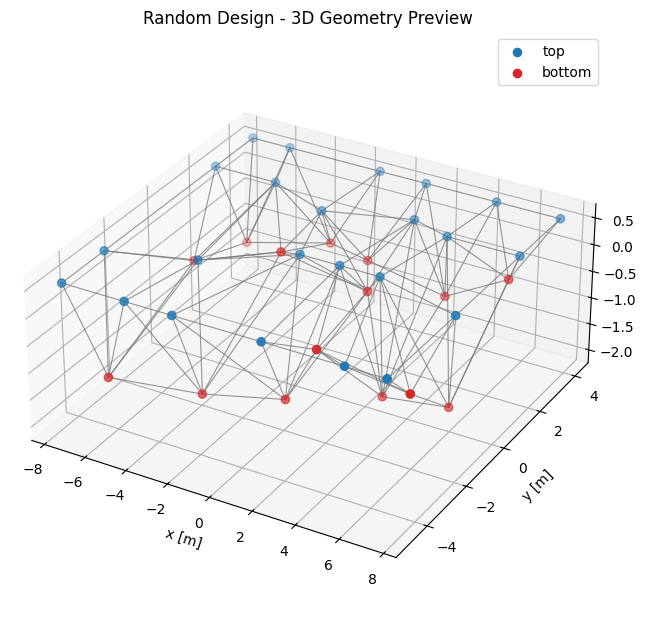

In [3]:
import importlib
import matplotlib.pyplot as plt
import c24_stage_geometry as stage_geometry

importlib.reload(stage_geometry)

geometry_out = stage_geometry.run_random_geometry_stage(
    json_path=json_path if "json_path" in globals() else None,
    optimizer_search_space=optimizer_search_space if "optimizer_search_space" in globals() else None,
    sample_id=0,
)

my_random_design = geometry_out["my_random_design"]
vertices_list = geometry_out["vertices_list"]
df_vertices = geometry_out["df_vertices"]
df_edges = geometry_out["df_edges"]
df_geometry_overview = geometry_out["df_geometry_overview"]

print(f"Geometry: {len(df_vertices)} nodes, {len(df_edges)} members")
print(
    f"Length range [m]: {df_geometry_overview['length_m'].min():.3f}"
    f" - {df_geometry_overview['length_m'].max():.3f}"
)
display(df_geometry_overview[["edge_id", "V1", "V2", "length_m"]].head(5))

fig, ax = stage_geometry.plot_geometry_preview(
    df_vertices=df_vertices,
    df_edges=df_edges,
    figsize=(8, 7),
)
plt.show()

# Feasibility check

In [4]:
import importlib
import c25_feasibility_check as feasibility_check
from workflows import c25_stage_feasibility as stage_feasibility

importlib.reload(feasibility_check)
importlib.reload(stage_feasibility)

MODEL_PREFIX_COMPLEX = "ID20260418_215020_LR0.0005_EP100_R0.99_F6"
MODEL_PREFIX_SIMPLE = "ID20260421_193347_LR0.0005_EP150_R0.99_F5"
SURROGATE_EDGE_FEATURE_MODE = "area_length"  # switch to "length_only" for the simple model

feasibility_out = stage_feasibility.run_feasibility_stage(
    df_input_stock=df_input_stock,
    df_vertices=df_vertices,
    df_edges=df_edges,
    model_prefix_complex=MODEL_PREFIX_COMPLEX,
    model_prefix_simple=MODEL_PREFIX_SIMPLE,
    gnn_margin=1.10,
    utilization_threshold=1.00,
    export_slots_path=None,
    force_mode="surrogate",
    surrogate_edge_feature_mode=SURROGATE_EDGE_FEATURE_MODE,
)

# Compatibility variables used by downstream cost/milp cells
SURROGATE_BUNDLE = feasibility_out["bundle"]
df_forces = feasibility_out["df_forces"]
df_slots = feasibility_out["df_slots"]
df_utilization_long = feasibility_out["df_utilization_long"]
df_utilization_matrix = feasibility_out["df_utilization_matrix"]
df_utilization_matrix_values = feasibility_out["df_utilization_matrix_values"]
df_feasibility_matrix = feasibility_out["df_feasibility_matrix"]
df_feasibility_matrix_values = feasibility_out["df_feasibility_matrix_values"]
df_safe_options = feasibility_out["df_safe_options"]
df_failure_reasons = feasibility_out["df_failure_reasons"]
feasibility_summary = feasibility_out["summary"]

print(
    f"C25 feasibility: {feasibility_summary['slots']} slots x {feasibility_summary['stock_items']} stock, "
    f"feasible pairs={feasibility_summary['feasible_pairs']}/{feasibility_summary['total_pairs']} "
    f"(utilization <= {feasibility_summary['utilization_threshold']:.2f})"
)
display(df_slots.head(5))
display(df_utilization_matrix.head(5))

# Export feasibility artifacts for downstream reporting/auditing
export_dir = config.EXPORT_PATH
export_dir.mkdir(parents=True, exist_ok=True)

target_edge_for_failure = "e24"
feasibility_matrix_path = export_dir / f"c25_feasibility_matrix_{SURROGATE_EDGE_FEATURE_MODE}.csv"
structure_slots_path = export_dir / f"c25_structure_slots_{SURROGATE_EDGE_FEATURE_MODE}.csv"
utilization_matrix_path = export_dir / f"c25_utilization_matrix_{SURROGATE_EDGE_FEATURE_MODE}.csv"
failure_reasons_path = export_dir / f"c25_failure_reasons_edge_{target_edge_for_failure}_{SURROGATE_EDGE_FEATURE_MODE}.csv"

df_feasibility_matrix.to_csv(feasibility_matrix_path, index=True)
df_slots.to_csv(structure_slots_path, index=False)
df_utilization_matrix.to_csv(utilization_matrix_path, index=True)

failure_reasons_edge = df_failure_reasons[
    df_failure_reasons["edge_id"].astype(str).str.strip().str.lower() == target_edge_for_failure.lower()
]
failure_reasons_edge.to_csv(failure_reasons_path, index=False)

print(f"Exported feasibility matrix: {feasibility_matrix_path}")
print(f"Exported structure slots: {structure_slots_path}")
print(f"Exported utilization matrix: {utilization_matrix_path}")
print(
    f"Exported failure reasons for {target_edge_for_failure}: {failure_reasons_path} "
    f"(rows={len(failure_reasons_edge)})"
)

c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using surrogate model prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6 with edge feature mode: area_length


RuntimeError: Failed to load surrogate bundle 'ID20260418_215020_LR0.0005_EP100_R0.99_F6': No checkpoint found for prefix 'ID20260418_215020_LR0.0005_EP100_R0.99_F6'.

## Surrogate model testing

In [ ]:
# -------------------------------
# DIAGNOSTIC: LENGTH-ONLY vs AREA-LENGTH
# -------------------------------
import numpy as np
import pandas as pd

# Re-run both modes on the same geometry + stock for an apples-to-apples comparison.
compare_modes = ["area_length", "length_only"]
mode_outputs = {}

for mode in compare_modes:
    print(f"\nRunning diagnostic feasibility for mode: {mode}")
    mode_outputs[mode] = stage_feasibility.run_feasibility_stage(
        df_input_stock=df_input_stock,
        df_vertices=df_vertices,
        df_edges=df_edges,
        model_prefix_complex=MODEL_PREFIX_COMPLEX,
        model_prefix_simple=MODEL_PREFIX_SIMPLE,
        gnn_margin=1.10,
        utilization_threshold=1.00,
        export_slots_path=None,
        force_mode="surrogate",
        surrogate_edge_feature_mode=mode,
    )


def _series_stats(values: np.ndarray) -> dict[str, float]:
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return {"count": 0, "min": np.nan, "q05": np.nan, "median": np.nan, "q95": np.nan, "max": np.nan, "mean": np.nan}
    return {
        "count": int(finite.size),
        "min": float(np.min(finite)),
        "q05": float(np.quantile(finite, 0.05)),
        "median": float(np.median(finite)),
        "q95": float(np.quantile(finite, 0.95)),
        "max": float(np.max(finite)),
        "mean": float(np.mean(finite)),
    }

# 1) Force comparison per edge
forces_area = mode_outputs["area_length"]["df_forces"][["edge_id", "axial_force_kn"]].rename(columns={"axial_force_kn": "axial_force_area"})
forces_len = mode_outputs["length_only"]["df_forces"][["edge_id", "axial_force_kn"]].rename(columns={"axial_force_kn": "axial_force_length"})

force_cmp = forces_area.merge(forces_len, on="edge_id", how="inner")
force_cmp["delta_kn"] = force_cmp["axial_force_length"] - force_cmp["axial_force_area"]
force_cmp["abs_delta_kn"] = force_cmp["delta_kn"].abs()
force_cmp["rel_delta_vs_area"] = force_cmp["delta_kn"] / force_cmp["axial_force_area"].replace(0.0, np.nan)

# 2) Utilization distribution comparison
util_stats_rows = []
for mode in compare_modes:
    util_vals = np.asarray(mode_outputs[mode]["df_utilization_matrix_values"], dtype=float).reshape(-1)
    row = {"mode": mode, **_series_stats(util_vals)}
    util_stats_rows.append(row)
util_stats = pd.DataFrame(util_stats_rows)

# 3) Force distribution comparison
force_stats_rows = []
for mode in compare_modes:
    force_vals = np.asarray(mode_outputs[mode]["df_forces"]["axial_force_kn"], dtype=float)
    row = {"mode": mode, **_series_stats(force_vals)}
    force_stats_rows.append(row)
force_stats = pd.DataFrame(force_stats_rows)

print("\nForce distribution by mode:")
display(force_stats)

print("\nUtilization distribution by mode:")
display(util_stats)

print("\nTop 10 edges by absolute force delta (length_only - area_length):")
display(force_cmp.sort_values("abs_delta_kn", ascending=False).head(10))

# Export diagnostic artifacts
diag_dir = config.EXPORT_PATH
diag_dir.mkdir(parents=True, exist_ok=True)

force_cmp_path = diag_dir / "c25_diagnostic_force_compare_length_vs_area.csv"
force_stats_path = diag_dir / "c25_diagnostic_force_stats_by_mode.csv"
util_stats_path = diag_dir / "c25_diagnostic_utilization_stats_by_mode.csv"

force_cmp.to_csv(force_cmp_path, index=False)
force_stats.to_csv(force_stats_path, index=False)
util_stats.to_csv(util_stats_path, index=False)

print(f"Exported force comparison: {force_cmp_path}")
print(f"Exported force stats: {force_stats_path}")
print(f"Exported utilization stats: {util_stats_path}")

In [ ]:
# -------------------------------
# DIAGNOSTIC: PREDICTIONS vs RECONSTRUCTED TEST TARGETS
# -------------------------------
import numpy as np
import pandas as pd
import c21_surrogate_io as surrogate_io


def _dist(values: np.ndarray) -> dict[str, float]:
    v = values[np.isfinite(values)]
    if v.size == 0:
        return {"count": 0, "min": np.nan, "q05": np.nan, "median": np.nan, "q95": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan}
    return {
        "count": int(v.size),
        "min": float(np.min(v)),
        "q05": float(np.quantile(v, 0.05)),
        "median": float(np.median(v)),
        "q95": float(np.quantile(v, 0.95)),
        "max": float(np.max(v)),
        "mean": float(np.mean(v)),
        "std": float(np.std(v)),
    }


def _resolve_mode_prefix(mode: str) -> str:
    if mode == "area_length":
        return MODEL_PREFIX_COMPLEX
    return MODEL_PREFIX_SIMPLE


def _reconstruct_test_targets(prefix: str) -> tuple[np.ndarray, dict[str, object]]:
    bundle = surrogate_io.load_surrogate_bundle(prefix_sm=prefix)
    manifest = bundle.get("run_manifest") or {}

    data_sources = manifest.get("dataset_sources") or {}
    edge_name = data_sources.get("edge")
    if edge_name is None:
        raise ValueError(f"No edge dataset source recorded in manifest for prefix {prefix}")

    edge_csv = config.GH_DATA_PATH / edge_name
    if not edge_csv.exists():
        raise FileNotFoundError(f"Edge source file not found: {edge_csv}")

    df_edge = pd.read_csv(edge_csv)
    sample_col = "Sample_ID" if "Sample_ID" in df_edge.columns else "sample_id"
    if sample_col not in df_edge.columns:
        raise ValueError(f"Edge source {edge_csv.name} misses sample id column (Sample_ID/sample_id)")

    target_col = str(manifest.get("target_col", "Axial_Force"))
    if target_col not in df_edge.columns:
        raise ValueError(f"Edge source {edge_csv.name} misses target column {target_col}")

    random_seed = int(manifest.get("random_seed", 42))
    train_split_ratio = float(manifest.get("train_split_ratio", 0.8))

    sample_ids = sorted(df_edge[sample_col].dropna().astype(int).unique().tolist())
    rng = np.random.default_rng(random_seed)
    shuffled = np.array(rng.permutation(sample_ids), dtype=int)
    train_size = int(train_split_ratio * len(shuffled))
    test_ids = set(shuffled[train_size:].tolist())

    y_test = df_edge.loc[df_edge[sample_col].astype(int).isin(test_ids), target_col].to_numpy(dtype=float)

    meta = {
        "prefix": prefix,
        "edge_source": str(edge_csv),
        "target_col": target_col,
        "random_seed_used": random_seed,
        "train_split_ratio_used": train_split_ratio,
        "n_samples_total": int(len(sample_ids)),
        "n_samples_test": int(len(test_ids)),
        "n_edges_test": int(y_test.size),
        "manifest_has_random_seed": bool("random_seed" in manifest),
        "manifest_has_train_split_ratio": bool("train_split_ratio" in manifest),
    }
    return y_test, meta


rows = []
for mode in ["area_length", "length_only"]:
    prefix = _resolve_mode_prefix(mode)
    y_test, meta = _reconstruct_test_targets(prefix)

    # Use already computed force predictions from previous diagnostic cell when available.
    if "mode_outputs" in globals() and mode in mode_outputs:
        y_pred = mode_outputs[mode]["df_forces"]["axial_force_kn"].to_numpy(dtype=float)
    else:
        tmp = stage_feasibility.run_feasibility_stage(
            df_input_stock=df_input_stock,
            df_vertices=df_vertices,
            df_edges=df_edges,
            model_prefix_complex=MODEL_PREFIX_COMPLEX,
            model_prefix_simple=MODEL_PREFIX_SIMPLE,
            gnn_margin=1.10,
            utilization_threshold=1.00,
            export_slots_path=None,
            force_mode="surrogate",
            surrogate_edge_feature_mode=mode,
        )
        y_pred = tmp["df_forces"]["axial_force_kn"].to_numpy(dtype=float)

    test_stats = _dist(y_test)
    pred_stats = _dist(y_pred)

    test_min, test_max = test_stats["min"], test_stats["max"]
    pred_outside = int(np.sum((y_pred < test_min) | (y_pred > test_max))) if np.isfinite(test_min) and np.isfinite(test_max) else np.nan

    rows.append({
        "mode": mode,
        "prefix": prefix,
        "test_count": test_stats["count"],
        "test_min": test_stats["min"],
        "test_q05": test_stats["q05"],
        "test_median": test_stats["median"],
        "test_q95": test_stats["q95"],
        "test_max": test_stats["max"],
        "test_mean": test_stats["mean"],
        "test_std": test_stats["std"],
        "pred_count": pred_stats["count"],
        "pred_min": pred_stats["min"],
        "pred_q05": pred_stats["q05"],
        "pred_median": pred_stats["median"],
        "pred_q95": pred_stats["q95"],
        "pred_max": pred_stats["max"],
        "pred_mean": pred_stats["mean"],
        "pred_std": pred_stats["std"],
        "pred_outside_test_range_count": pred_outside,
        "random_seed_used": meta["random_seed_used"],
        "train_split_ratio_used": meta["train_split_ratio_used"],
        "manifest_has_random_seed": meta["manifest_has_random_seed"],
        "manifest_has_train_split_ratio": meta["manifest_has_train_split_ratio"],
    })

summary_compare = pd.DataFrame(rows)

print("Reconstructed test-target vs current-geometry prediction distribution:")
display(summary_compare)

if not bool(summary_compare["manifest_has_random_seed"].all()) or not bool(summary_compare["manifest_has_train_split_ratio"].all()):
    print("WARNING: run manifests do not store split seed/ratio explicitly; diagnostic used fallback seed=42 and split=0.8 from training convention.")

summary_compare_path = config.EXPORT_PATH / "c25_diagnostic_pred_vs_reconstructed_test_distribution.csv"
summary_compare.to_csv(summary_compare_path, index=False)
print(f"Exported reconstructed-test comparison: {summary_compare_path}")

# COST, MATCHING AND FITNESS

In [ ]:
import importlib
import json
import pandas as pd
import config
from workflows import c26_stage_cost_matrix as stage_cost
from workflows import c27_stage_milp as stage_milp
from workflows import c28_stage_fitness as stage_fitness

importlib.reload(stage_cost)
importlib.reload(stage_milp)
importlib.reload(stage_fitness)

# -------------------------------
# STEP 1: COST MATRIX STAGE
# -------------------------------
target_slot_for_analysis = "e20"

cost_out = stage_cost.run_cost_matrix_stage(
    df_slots=df_slots,
    df_input_stock=df_input_stock,
    df_utilization_matrix=df_utilization_matrix_values if "df_utilization_matrix_values" in globals() else df_utilization_matrix,
    utilization_threshold=1.00,
    cost_formula_version="v2",
    include_threshold_sweep=False,
    export_slot_analysis=True,
    target_slot_for_analysis=target_slot_for_analysis,
    export_dir=config.EXPORT_PATH,
    quiet=True,
)

cost_matrix = cost_out["cost_matrix"]
enriched_stock = cost_out["enriched_stock"]
df_logs = cost_out["df_logs"]
df_cost_matrix_display = cost_out["df_cost_matrix_display"]
df_threshold_sweep = cost_out["df_threshold_sweep"]
slot_analysis = cost_out["slot_analysis"]
cost_summary = cost_out["summary"]

# Notebook-owned exports
export_dir = config.EXPORT_PATH
export_dir.mkdir(parents=True, exist_ok=True)
final_cost_matrix_path = export_dir / "c26_final_cost_matrix.csv"
df_cost_matrix_display.to_csv(final_cost_matrix_path, index=True)
print(f"Exported final cost matrix: {final_cost_matrix_path}")

if slot_analysis is not None:
    slot_analysis_path = slot_analysis["analysis_export_path"]
    slot_analysis["df_logs_slot"].to_csv(slot_analysis_path, index=False)
    print(f"Exported slot analysis: {slot_analysis_path}")
    if slot_analysis.get("df_logs_slot_rs") is not None and len(slot_analysis["df_logs_slot_rs"]) > 0:
        rs_analysis_path = slot_analysis_path.with_name(f"{slot_analysis_path.stem}_rs.csv")
        slot_analysis["df_logs_slot_rs"].to_csv(rs_analysis_path, index=False)
        print(f"Exported RS slot analysis: {rs_analysis_path}")

if df_threshold_sweep is not None and len(df_threshold_sweep) > 0:
    threshold_sweep_path = export_dir / "c26_threshold_sweep.csv"
    df_threshold_sweep.to_csv(threshold_sweep_path, index=False)
    print(f"Exported threshold sweep: {threshold_sweep_path}")

print(
    f"Cost matrix: {cost_summary['slots']} slots x {cost_summary['stock_items']} stock, "
    f"valid={cost_summary['valid_pairs']}/{cost_summary['total_pairs']} "
    f"(pruned={cost_summary.get('pruned_pairs', 0)}), "
    f"utilization_mode={cost_summary.get('utilization_mode', 'unknown')}, "
    f"cost_formula_version={cost_summary.get('cost_formula_version', 'unknown')}"
)

if df_threshold_sweep is not None and len(df_threshold_sweep) > 0:
    print("Threshold sweep summary:")
    display(df_threshold_sweep)

if slot_analysis is not None:
    print(f"Detailed slot analysis prepared: {slot_analysis['analysis_export_path']}")

# -------------------------------
# STEP 2: MILP STAGE
# -------------------------------
print("Starting MILP optimizer...")
milp_out = stage_milp.run_milp_stage(
    cost_matrix=cost_matrix,
    enriched_stock=enriched_stock,
    df_slots=df_slots,
    reclaimed_marker="RS",
    new_marker="NS",
    new_stock_max_uses=100,
    solver_msg=False,
    raise_on_infeasible_slots=True,
)

status = milp_out["status"]
df_results = milp_out["df_results"]
total_cost = milp_out["total_cost"]
milp_summary = milp_out["summary"]

df_results.to_csv(config.EXPORT_PATH / "c27_milp_results.csv", index=False)

print(
    f"MILP setup: {milp_summary['reclaimed_items']} reclaimed + "
    f"{milp_summary['new_items']} new stock items for {milp_summary['slots']} slots"
)
print(f"MILP status: {status}")
print(f"Total assignment cost: {total_cost:.2f}")
if len(df_results) > 0:
    display(df_results.head(10))

In [ ]:
# -------------------------------
# STEP 2.5: FITNESS NORMALIZATION BOUNDS
# -------------------------------
from workflows import c28_stage_normalization_bounds as stage_bounds

bounds_out = stage_bounds.run_normalization_bounds_stage(
    cost_matrix=cost_matrix,
    df_logs=df_logs,
    enriched_stock=enriched_stock,
    df_slots=df_slots,
    reclaimed_marker="RS",
    new_marker="NS",
    new_stock_max_uses=100,   # match your c27 call
    solver_msg=False,
    print_summary=True,
)

normalization_constants = bounds_out["normalization_constants"]
print(normalization_constants)
# -> {"C_max": ..., "R_max": ..., "W_max": ...}

In [ ]:
# -------------------------------
# STEP 3: FITNESS STAGE
# -------------------------------
fitness_weights = {
    "omega_1": 1.0,
    "omega_2": 1.0,
    "omega_3": 1.0,
}

fitness_out = stage_fitness.run_fitness_stage(
    df_results=df_results,
    enriched_stock=enriched_stock,
    df_slots=df_slots,
    total_cost=total_cost,
    weight_config=fitness_weights,
    normalization_constants=normalization_constants,
    derive_normalization_constants=False,
    run_sanity_checks=True,
    print_breakdown=True,
)

fitness_result = fitness_out["fitness_result"]
normalization_constants = fitness_out["normalization_constants"]

print("Fitness summary:")
print(f"  objective: {fitness_result.get('objective', 'n/a')}")
print(f"  feasible: {fitness_result.get('is_feasible', 'n/a')}")
print(f"  fitness: {fitness_result.get('fitness', 'n/a')}\n")

# Notebook-owned fitness exports
fitness_json_path = config.EXPORT_PATH / "c28_fitness_result.json"
fitness_csv_path = config.EXPORT_PATH / "c28_fitness_result.csv"

fitness_json_path.parent.mkdir(parents=True, exist_ok=True)

# Convert numpy scalars to native Python values for stable JSON serialization.
def _to_builtin(value):
    return value.item() if hasattr(value, "item") else value

fitness_export = {key: _to_builtin(value) for key, value in fitness_result.items()}
fitness_export["weights"] = {
    "omega_1": float(fitness_weights["omega_1"]),
    "omega_2": float(fitness_weights["omega_2"]),
    "omega_3": float(fitness_weights["omega_3"]),
}
fitness_export["normalization_constants"] = {
    "C_max": float(normalization_constants["C_max"]),
    "R_max": float(normalization_constants["R_max"]),
    "W_max": float(normalization_constants["W_max"]),
}

with open(fitness_json_path, "w", encoding="utf-8") as f:
    json.dump(fitness_export, f, indent=2)

fitness_row = {
    **{key: _to_builtin(value) for key, value in fitness_result.items()},
    **fitness_weights,
    "C_max": float(normalization_constants["C_max"]),
    "R_max": float(normalization_constants["R_max"]),
    "W_max": float(normalization_constants["W_max"]),
}
pd.DataFrame([fitness_row]).to_csv(fitness_csv_path, index=False)

print(f"Exported fitness JSON: {fitness_json_path}")
print(f"Exported fitness CSV: {fitness_csv_path}")

# EXPORT

Exports structural parameters (vertices + edges with assigned timber) for Grasshopper reconstruction.

In [ ]:
# Export geometry + matching results
import pandas as pd
import config

EXPORT_PREFIX = "c29_optimum"
required_vars = ["df_vertices", "df_edges", "df_results"]
if any(name not in globals() for name in required_vars):
    raise ValueError(f"Missing: {', '.join(required_vars)}")

df_edges_export = pd.merge(df_edges, df_results[["edge_id", "assigned_timber", "CO2_Penalty"]], on="edge_id", how="left")
df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna("UNASSIGNED")
df_edges_export["CO2_Penalty"] = df_edges_export["CO2_Penalty"].fillna(0)

df_vertices.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv", index=False)
df_edges_export.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges.csv", index=False)
n_matched = int((df_edges_export["assigned_timber"] != "UNASSIGNED").sum())
print(f"Exported: {len(df_vertices)} vertices, {len(df_edges_export)} edges ({n_matched} matched)")

# LITERATURE

### COST MATRIX
We now use one universal assignment formula for both reclaimed and new timber in the same cost matrix:

$$C_{i,j} = E_{embodied,i} + E_{prep,i} + E_{trans,i,j} + E_{waste,i,j} + E_{saw,i,j}$$

With:
- $E_{embodied,i} = V_{stock,i} \cdot M_{material,i}$ (from `ECC` in stock data)
- $E_{prep,i} = V_{stock,i} \cdot E_{prep}$
- $E_{trans,i,j} = \left(\frac{(V_{req}+V_{over})\cdot\rho}{1000}\right)\cdot D\cdot F_{trans}$
- $E_{waste,i,j} = V_{waste} \cdot E_{EoL}$
- $E_{saw,i,j} = P_{cut}$ when cutting is required, else 0

Interpretation by timber type:
- New timber: typically high `ECC`, usually low/zero preparation factor
- Reclaimed timber: `ECC` near 0, non-zero preparation factor

### MATCHING ALGORITHM / MILP
The assignment problem in this notebook is solved as a mixed-integer linear program (MILP). Let:

- $I$ be the set of required structural slots,
- $J$ be the set of inventory stock elements,
- $F \subseteq I \times J$ be the set of physically feasible slot-stock combinations,
- $R \subseteq J$ be the subset of reclaimed timber,
- $N \subseteq J$ be the subset of new timber,
- $c_{ij}$ be the cost of assigning stock element $j$ to slot $i$,
- $x_{ij} \in \{0,1\}$ be the decision variable, where $x_{ij}=1$ means that stock element $j$ is assigned to slot $i$.

$$
\min_{x} \sum_{(i,j) \in F} c_{ij} x_{ij}
$$

subject to

$$
\sum_{j:(i,j)\in F} x_{ij} = 1 \qquad \forall i \in I
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le 1 \qquad \forall j \in R
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le |I| \qquad \forall j \in N
$$

$$
x_{ij} = 0 \qquad \forall (i,j) \notin F
$$

In words: every structural member must receive exactly one feasible timber element, reclaimed timber can be used at most once, and new timber can be reused when physically feasible.

### MULTI-OBJECTIVE FITNESS FUNCTION

The fitness function balances three competing objectives:

$$F(\mathbf{x}) = \omega_1 \left( \frac{f_{inner}^*(\mathbf{x})}{\mathcal{C}_{max}} \right) - \omega_2 \left( \frac{\mathcal{R}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{R}_{max}} \right) + \omega_3 \left( \frac{\mathcal{W}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{W}_{max}} \right)$$

- **$f_{inner}^*$**: MILP cost (kg CO2e) — penalizes virgin material and waste
- **$\mathcal{R}$**: Reuse rate (%) — reward for using reclaimed timber (subtracted, so higher reuse = better)
- **$\mathcal{W}$**: Total waste (m³) — penalizes inefficient cutting
- **$\omega_i$**: Weight coefficients to tune priorities

All metrics are normalized to [0, 1] using precomputed dataset-driven extremes ($\mathcal{C}_{max}$, $\mathcal{R}_{max}$, $\mathcal{W}_{max}$).

**Design philosophy**: The MILP cost matrix already accounts for all physical and geometric infeasibilities (by returning ∞ for impossible assignments). This means the upper-level fitness function does NOT need a conditional fallback loop. Instead, we can directly minimize a weighted multi-objective sum.

**Sign convention**:
- Positive coefficient on cost: higher MILP cost → higher (worse) fitness
- Negative coefficient on reuse: higher reuse rate → lower (better) fitness ✓
- Positive coefficient on waste: higher waste → higher (worse) fitness

**Typical design trade-offs**:
- High ω₁ (cost weight): prioritize LCA minimization across all materials
- High ω₂ (reuse weight): prioritize reclaimed material recovery
- High ω₃ (waste weight): prioritize cutting efficiency